# Functional Capstone Project - Data & Analytics



## Business Context

**Infini Telco** is a prominent player in the telco industry with a strong presence in Malaysia. Specializing in B2B sales, they serve as a vital link in the supply chain, facilitating the distribution of telecommunication and technology products to retailers, service providers, and other businesses across the continent.

Despite their market dominance and expansive product offerings, the company faces critical business challenge related to marketing strategy. A key aspect of this involves the ***identification and segmentation of their customer base into well-defined segments based on discernible patterns in product purchase behaviour and understand their product portfolio.*** By understanding the distinct needs, preferences, and purchasing habits of different customer segments, the client can develop targeted marketing strategies that cater to the specific needs of each segment, enhancing customer satisfaction and loyalty, driving revenue growth.




## Business Challenges

- No streamlined process to handle data and data is only available in chunks
- Limited intel on customer purchase patterns to drive targeted marketing
- Inadequate product insights across different customer groups


## Project Objectives

The business needs your help as a ***data analyst*** to overcome these challenges. Apply your data analytics skillset learnt.



# **1. Data Preprocessing**

Data preparation is a critical process first step, involving the gathering, cleaning, transforming, and organizing of raw data into a format suitable for analysis. This step is essential for ensuring the quality and reliability of the insights derived from the data.

Here, the transaction data is provided from June 2020 to December 2022, which are stored across three separate csv files. The dataset are:

- Transactions_1.csv
- Transactions_2.csv
- Transactions_3.csv

***Task 1.1: Combine the transaction data files***

Find a way to combine the above data together into a singular dataframe, that will contain all the transactions at one place. Name this singular dataframe df_Txn_full.

In [ ]:
#Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_rows = 100

In [ ]:
import pandas as pd

#load dataset, skipping bad lines to prevent ParserError
df1 = pd.read_csv("Transactions_1.csv")
df2 = pd.read_csv("Transactions_2.csv")
df3 = pd.read_csv("Transactions_3.csv")

In [ ]:
#combined the datasets
df_Txn_full = pd.concat([df1, df2, df3], ignore_index=True)
df_Txn_full.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,000000000000100095,ZSV,0.00,1
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,0
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.00,1


In [ ]:
#check the combined shape and info
print("Rows:", df_Txn_full.shape[0])
print("Columns:", df_Txn_full.shape[1])
df_Txn_full.info()

Rows: 1353671
Columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353671 entries, 0 to 1353670
Data columns (total 12 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   INDEX                          1353671 non-null  int64  
 1   INVOICE_NUMBER                 1353671 non-null  int64  
 2   INVOICE_ITEM                   1353671 non-null  int64  
 3   DOCUMENT_DATE                  1353671 non-null  object 
 4   CUSTOMER_NUMBER                1353671 non-null  int64  
 5   Main_account                   1353671 non-null  int64  
 6   Main_account_name              1353671 non-null  object 
 7   Main_resposible_employee_name  1353671 non-null  object 
 8   PRODUCT                        1353671 non-null  object 
 9   Position_type_order_line       1353671 non-null  object 
 10  GROSS_TURNOVER                 1353671 non-null  float64
 11  AMOUNT                         1353671 non-null  i

**Validation checkpoints:**
Consider, you would have received some information from the business on:

- Gross Annual Turnover for this period to be ~$1.4B
- The total unique products are ~190000
- The total customer base is ~7k

***Task 1.1.1***:

Use the above information to validate the data creation process. This is to ensure that no records of data are lost in the process.

In [ ]:
#validation
print("Gross Turnover:", df_Txn_full["GROSS_TURNOVER"].sum())
print("Unique Products:", df_Txn_full["PRODUCT"].nunique())
print("Unique Customers:", df_Txn_full["CUSTOMER_NUMBER"].nunique())

Gross Turnover: 1466478196.7234998
Unique Products: 191394
Unique Customers: 7130


***Task 1.2: Join the mapping files to the transaction data***


Mapping files contain supplementary detailed information that will be used for our analysis.
Use these mapping files to join with the above transaction data to create the master dataset <br><br>
**List of mapping files and their primary keys:**<br>
1. Customer Characteristics : to be joined on Customer Number
2. Customer Type Mapping : to be joined on Main Account ID
3. Product Category Mapping : to be joined on Product ID

To ensure that the joins are performed accurately, it is a good practice to clean up the columns upon which the join is performed.
Some recommended steps to clean up a column are:

- ensuring the values are of the same data type
- removing leading zeroes
- removing leading and trailing whitespaces etc.


***Task 1.2.1:***

Here, before, performing the joins, you have to perform an intermediary step to clean up the below columns based on the above recommended steps:

- customer_number
- Product
- Main_account
- Invoice_Number

*Hint: Check for any leading or trailing 0s or white spaces.*

In [ ]:
#cleaning function for key columns

def clean_key_column(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.lstrip("0")
    )

#clean the transactional key columns
df_Txn_full["CUSTOMER_NUMBER"] = clean_key_column(
    df_Txn_full["CUSTOMER_NUMBER"]
)

df_Txn_full["PRODUCT"] = clean_key_column(
    df_Txn_full["PRODUCT"]
)

df_Txn_full["Main_account"] = clean_key_column(
    df_Txn_full["Main_account"]
)

df_Txn_full["INVOICE_NUMBER"] = clean_key_column(
    df_Txn_full["INVOICE_NUMBER"]
)


In [ ]:
#check the cleaned columns
df_Txn_full[["CUSTOMER_NUMBER", "PRODUCT", "Main_account", "INVOICE_NUMBER"]].head()

,CUSTOMER_NUMBER,PRODUCT,Main_account,INVOICE_NUMBER
0,14816,100095,14816,124289578
1,17566,100095,17566,124317609
2,17566,100095,17566,124317609
3,17566,100095,17566,124317609
4,17566,100095,17566,124317609


***Task 1.2.2:***

Import the mapping files and rename the dataframe:

- Customer Characteristics.csv : df_CustChar
- Customer Type Mapping.csv : df_CustType
- Product Categories.csv : df_ProdCategories

In [ ]:
#import mapping files

df_CustChar = pd.read_csv(
    "Customer Characteristics.csv",
    encoding="latin1"
)

df_CustType = pd.read_csv(
    "Customer Type Mapping.csv",
    encoding="latin1"
)

df_ProdCategories = pd.read_csv(
    "Product Categories.csv",
    encoding="latin1"
)

In [ ]:
#check the mapping files
print(df_CustChar.shape)
print(df_CustType.shape)
print(df_ProdCategories.shape)


(7130, 4)
(6855, 2)
(210028, 4)


In [ ]:
display(df_CustChar.head())
display(df_CustType.head())
display(df_ProdCategories.head())

,CUSTOMER_NAME,CUSTOMER_NUMBER,ACCOUNT_GROUP_TXT,CVR_Company_status
0,CUSTOMER_NAME_0,35016,Debtors,Normal
1,CUSTOMER_NAME_1,38336,Debtors,Normal
2,CUSTOMER_NAME_2,38438,Debtors,Normal
3,CUSTOMER_NAME_3,45001,Debtors,Normal
4,CUSTOMER_NAME_2,45005,Debtors,Normal


,Main_account_ID,Customer_type
0,10014,A-B
1,10025,A-B
2,10033,A-B
3,10048,D
4,10056,C


,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,000000010001151351,739,Web Conferencing Services,Communication Tools
1,000000010000802665,739,Web Conferencing Services,Communication Tools
2,000000000614529000,739,Web Conferencing Services,Communication Tools
3,000000000617092230,739,Web Conferencing Services,Communication Tools
4,000000000605040414,739,Web Conferencing Services,Communication Tools


***Task 1.2.3:***

To perform join on the dataframes, it is important to clean the columns to ensure that the columns are free from any special characters.

- Remove any leading or trailing 0s in Customer_Number column in the df_CustChar dataframe.
- Check for duplicates in the data and remove any duplicates.
- Create a master dataframe by performing appropriate join on df_CustChar dataframe and df_Txn_full dataframe. Rename the master dataframe as df_Master.



In [ ]:
# clean customer number in transaction data
df_Txn_full["CUSTOMER_NUMBER"] = clean_key_column(df_Txn_full["CUSTOMER_NUMBER"])

# clean customer number in customer characteristics mapping file
df_CustChar["CUSTOMER_NUMBER"] = clean_key_column(df_CustChar["CUSTOMER_NUMBER"])

#check duplicate
df_CustChar.duplicated().sum()
print("Duplicate:", df_CustChar.duplicated().sum())

# create master dataframe
df_Master = df_Txn_full.merge(
    df_CustChar,
    how="left",
    on="CUSTOMER_NUMBER"
)

df_Master.head()

Duplicate: 0


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal


***Task 1.2.4:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [ ]:
# validation after join
print("Gross Turnover:", df_Master["GROSS_TURNOVER"].sum())
print("Unique Customers:", df_Master["CUSTOMER_NUMBER"].nunique())

Gross Turnover: 1466478196.7234998
Unique Customers: 7130


***Task 1.2.5:***

Now, you will be joining the df_CustType dataframe with the master dataframe.

- Remove any leading or trailing 0s in Main_account_ID column in the df_CustType dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_CustType dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [ ]:
#clean customer type mapping
df_CustType["Main_account_ID"] = clean_key_column(df_CustType["Main_account_ID"])
df_CustType = df_CustType.drop_duplicates(subset=["Main_account_ID"])

#check dupliacte
df_CustType.duplicated().sum()

np.int64(0)

In [ ]:
#Join Customer Type
df_Master = df_Master.merge(
    df_CustType,
    how="left",
    left_on="Main_account",
    right_on="Main_account_ID"
)

df_Master.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,0.00,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,0.00,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B


***Task 1.2.6:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k

In [ ]:
print("Gross Turnover:", df_Master["GROSS_TURNOVER"].sum())
print("Unique Customers:", df_Master["CUSTOMER_NUMBER"].nunique())

Gross Turnover: 1466478196.7234998
Unique Customers: 7130


***Task 1.2.7:***

Now, you will be joining the df_ProdCategories dataframe with the master dataframe.

- Remove any leading or trailing 0s in ProductID column in the df_ProdCategories dataframe.
- Check for duplicates in the data and remove any duplicates.
- Perform appropriate join on df_ProdCategories dataframe and df_Master dataframe and save this merged dataframe as df_Master.

In [ ]:
# clean product key in transaction/master data
df_Master["PRODUCT"] = clean_key_column(df_Master["PRODUCT"])

# clean product key in product category mapping
df_ProdCategories["ProductID"] = clean_key_column(df_ProdCategories["ProductID"])

#check duplicate
df_ProdCategories.duplicated().sum()
print("Duplicate:", df_ProdCategories.duplicated().sum())


Duplicate: 0


In [ ]:
# merge product categories
df_Master = df_Master.merge(
    df_ProdCategories,
    how="left",
    left_on="PRODUCT",
    right_on="ProductID"
)

df_Master.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,AMOUNT,CUSTOMER_NAME,ACCOUNT_GROUP_TXT,CVR_Company_status,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1
0,33806,124289578,10,2022-10-01,14816,14816,Customer Group_0,Responsible Employee_0,100095,ZSV,...,1,CUSTOMER_NAME_1429,Debtors,Normal,14816,KAM,100095,8.00,Music Streaming Services,Television and Entertainment
1,65627,124317609,230,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
2,65628,124317609,250,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,0,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
3,65629,124317609,270,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment
4,65630,124317609,290,2022-10-01,17566,17566,Customer Group_1,Responsible Employee_1,100095,ZSV,...,1,CUSTOMER_NAME_573,Debtors,Normal,17566,A-B,100095,8.00,Music Streaming Services,Television and Entertainment


***Task 1.2.8:***

There is a data validation check point here. This is to ensure that you have not lost any data in the data preparation step.
Check and validate:

- Gross Annual Turnover is ~$1.4B
- The total customer base is ~7k
- The total product is ~15k

In [ ]:
print("Gross Turnover:", df_Master["GROSS_TURNOVER"].sum())
print("Unique Customers:", df_Master["CUSTOMER_NUMBER"].nunique())
print("Unique Products:", df_Master["PRODUCT"].nunique())

Gross Turnover: 1466478196.7234998
Unique Customers: 7130
Unique Products: 150545


***Task 1.3: Data Cleaning***

A major part of data pre processing involves cleaning the data, removing nulls, filtering out irrelavant or less useful information. For example:

- Remove rows with missing product id
- Removing rows with negative or zero turnover
- Removing customers who interacted very less

As part of Data Cleaning of this dataset you are required to perform the following:

***Task 1.3.1: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase less frequently

In [ ]:
#INVOICE FLAG
invoice_count = df_Master.groupby("Main_account")["INVOICE_NUMBER"].nunique()

df_Master["Invoice_count"] = df_Master["Main_account"].map(invoice_count)
df_Master["Invoice_flag"] = np.where(df_Master["Invoice_count"] <= 3, 0, 1)

df_Master[["Main_account", "Invoice_count", "Invoice_flag"]].head()

,Main_account,Invoice_count,Invoice_flag
0,14816,24,1
1,17566,1510,1
2,17566,1510,1
3,17566,1510,1
4,17566,1510,1


***Task 1.3.2: In the df_Master data, add a column Invoice_flag, reflecting 0 if number of transactions <= 3, otherwise 1***

This is to flag customers who purchase single SKU.

In [ ]:
#SKU FLAG
sku_count = df_Master.groupby("Main_account")["PRODUCT"].nunique()

df_Master["SKU_count"] = df_Master["Main_account"].map(sku_count)
df_Master["SKU_flag"] = np.where(df_Master["SKU_count"] <= 1, 0, 1)

df_Master[["Main_account", "SKU_count", "SKU_flag"]].head()

,Main_account,SKU_count,SKU_flag
0,14816,121,1
1,17566,2119,1
2,17566,2119,1
3,17566,2119,1
4,17566,2119,1


There are a few records in the dataset whose Product ID are null. These records won't map to product information from the mapping file and hence these records will not be useful for the analysis.

***Task 1.3.3: In the master data, remove records where Product ID is null and save it in a dataframe df_Filtered***

In [ ]:
#Remove missing Product ID
df_Filtered = df_Master[df_Master["PRODUCT"].notna()].copy()
df_Filtered.shape

(1353671, 25)

There are a few records that lack information on product category and will not be useful for the analysis

***Task 1.3.4: In the df_Filtered dataftame, remove records where Product Category information is null***


In [ ]:
df_Filtered = df_Filtered[df_Filtered["ProdCat1"].notna()].copy()
df_Filtered.shape

(1351546, 25)

There are some sales made to Internal accounts in the dataset. These sales can be removed from analysis as information on internal sales can distort the analysis of customer behaviour. Internal transactions do not reflect the actual market demand or customer preferences.

***Task 1.3.5: In the df_Filtered dataframe, remove records pertaining to sales to Internal Account***

*Hint: Check for Internal accounts in Account_Group_TXT field*

In [ ]:
df_Filtered = df_Filtered[
    ~df_Filtered["ACCOUNT_GROUP_TXT"].astype(str).str.contains("Internal", case=False, na=False)
].copy()

df_Filtered.shape

(1351157, 25)

As per business requirement, sales made to "ZSKA" and "ZDIR" are requested to be removed.

***Task 1.3.6: In the df_Filtered dataframe, remove records with position types "ZSKA" and "ZDIR"***

*Hint: Check column Position_type_order_line*

In [ ]:
df_Filtered = df_Filtered[
    ~df_Filtered["Position_type_order_line"].isin(["ZSKA", "ZDIR"])
].copy()

df_Filtered.shape

(1302530, 25)

Some companies are currently not active or are in normal operation. It makes sense to exclude these companies from analysis. But, for companies whose status is unknown (null/na), we still retain them.

***Task 1.3.7: In the df_Filtered dataframe, remove records whose company status are not active/normal***

*Hint: Check column CVR_Company_status*

In [ ]:
df_Filtered = df_Filtered[
    df_Filtered["CVR_Company_status"].isna()
    | df_Filtered["CVR_Company_status"].astype(str).str.contains("active|normal", case=False, na=False)
].copy()

df_Filtered.shape

(1302530, 25)

There might be some records where Gross Turnover is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.8: In the df_Filtered dataframe, remove records where Gross Turnover is zero or negative***

In [ ]:
df_Filtered = df_Filtered[df_Filtered["GROSS_TURNOVER"] > 0].copy()
df_Filtered.shape

(1273117, 25)

There might be some records where Amount is zero or negative. These records might indicate product returns/invalid entries and should be excluded from the analysis.

***Task 1.3.9: In the df_Filtered dataframe, remove records where Amount is zero or negative***


In [ ]:
df_Filtered = df_Filtered[df_Filtered["AMOUNT"] > 0].copy()
df_Filtered.shape

(1083193, 25)

Remember, you had created a column to flag the customers whose number of transactions are 3 or less than that. Customers with very few transactions may introduce noise into the data, making it harder to identify meaningful patterns and trends. Filtering out these customers results in a cleaner dataset, which enhances the accuracy and reliability of the analysis.

***Task 1.3.10: In the df_Filtered dataframe, filter out customers who have made 3 or fewer transactions***

*Hint: Utilize the Invoice_flag column created earlier.*

In [ ]:
df_Filtered = df_Filtered[df_Filtered["Invoice_flag"] == 1].copy()
df_Filtered.shape

(1078433, 25)

You had also created a column to flag the customers who purchased only one sku. Such records in the data also tends to add noise and is necesary to filter these customers out.

***Task 1.3.11: In the df_Filtered dataframe, filter out customers who have purchased only a single SKU***

*Hint: Utilize the SKU_flag column created earlier.*

In [ ]:
df_Filtered = df_Filtered[df_Filtered["SKU_flag"] == 1].copy()
df_Filtered.shape

(1078229, 25)

There are some information from the business and the business aligned on the fact that some very large customers are outliers and having them in the data could skew the analysis results. Hence, they should be filtered out. These customer types are denoted by KAM (Key Account Management).

***Task 1.3.12: In the df_Filtered dataframe, Filter out "Key" customer accounts***

*Hint: Check Customer_type column*

In [ ]:
df_Filtered = df_Filtered[
    ~df_Filtered["Customer_type"].astype(str).str.contains("KAM|Key", case=False, na=False)
].copy()

df_Filtered.shape

(841529, 25)

**With the above steps of data preprocessing, you now get a cleaned data set which will be used for further analysis.**

# **2. Data Transformation**


***Task 2.1: Based on what you have learnt previously, perform a series of standard EDA to gain a better understanding of the data***

In [ ]:
display(df_Filtered.describe(include="all"))

print("Rows:", df_Filtered.shape[0])
print("Customers:", df_Filtered["Main_account"].nunique())
print("Products:", df_Filtered["PRODUCT"].nunique())
print("Gross Turnover:", df_Filtered["GROSS_TURNOVER"].sum())

df_Filtered.groupby("ProdCat1")["GROSS_TURNOVER"].sum().sort_values(ascending=False).head(10)

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Invoice_count,Invoice_flag,SKU_count,SKU_flag
count,841529.00,841529,841529.00,841529,841529,841529,841529,841529,841529,841529,...,841529,834746,841529,841529.00,841529,841529,841529.00,841529.00,841529.00,841529.00
unique,NaN,323220,NaN,568,4572,4037,3792,87,99102,22,...,4037,3,99102,NaN,219,21,NaN,NaN,NaN,NaN
top,NaN,123935935,NaN,2022-06-15,590220,103350,Customer Group_24,Responsible Employee_2,4440610319,ZLAG,...,103350,A-B,4440610319,NaN,Mobile Plans (Prepaid),Television and Entertainment,NaN,NaN,NaN,NaN
freq,NaN,474,NaN,4567,14212,15281,15281,84029,1993,653263,...,15281,696178,1993,NaN,71615,146686,NaN,NaN,NaN,NaN
mean,702013.27,NaN,889.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,565.68,NaN,NaN,989.42,1.00,1516.86,1.00
std,398567.02,NaN,2411.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,241.68,NaN,NaN,1440.70,0.00,2018.50,0.00
min,1.00,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.00,NaN,NaN,4.00,1.00,2.00,1.00
25%,315697.00,NaN,50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,318.00,NaN,NaN,149.00,1.00,325.00,1.00
50%,731000.00,NaN,200.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,603.00,NaN,NaN,479.00,1.00,801.00,1.00
75%,1046090.00,NaN,840.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,756.00,NaN,NaN,1319.00,1.00,1752.00,1.00


Rows: 841529
Customers: 4037
Products: 99102
Gross Turnover: 933909302.7766997


,GROSS_TURNOVER
ProdCat1,
Network and Infrastructure,151883638.61
Television and Entertainment,124049753.87
Mobile Services,112107544.79
Broadband and Internet Services,92243494.56
Digital Transformation Services,74097793.86
Devices and Accessories,71898114.74
Business Solutions,71213227.81
Cloud and Hosting Services,65753107.71
Security and Privacy,44367740.39


## Pareto Analysis

**Pareto Analysis** is a strategic decision-making tool used to prioritize actions based on the principle that a small number of causes typically lead to a large portion of the effects. Known as the 80/20 rule or the Pareto Principle, this concept is highly applicable in customer and product management, helping businesses focus on the most impactful areas to maximize efficiency and profitability.

## Key Concepts


**i) Pareto Principle (80/20 Rule):**

In the context of customers and products, this principle suggests that roughly 80% of a company’s revenue comes from 20% of its customers or products. Understanding this can help businesses focus their efforts on the most valuable segments.

**ii) Pareto Chart:**

A Pareto chart is a graphical tool that helps visualize and prioritize the most significant factors among a set. It combines a bar graph and a line graph, where bars represent individual values in descending order, and the line shows the cumulative total.

***An example of Pareto Chart and Pareto Analysis:***

![image-2.png](attachment:image-2.png)

Here is the Pareto chart for products and their corresponding revenues. The chart consists of two key elements:

**Bar Chart:** The blue bars represent the individual revenue contributions of each product, sorted in descending order.

**Line Chart:** The red line shows the cumulative percentage of the total revenue contributed by the products. The horizontal
gray dashed line indicates the 80% mark.

***Analysis***

- Product Contribution: The first few products (A, B, and C) generate a significant portion of the revenue, highlighting the "vital few" that follow the Pareto Principle.
- Cumulative Percentage: By the time we include Product E, the cumulative revenue reaches around 80% of the total, illustrating that a small number of products contribute to the majority of the revenue.

***Implications***

- Focus on Key Products: Efforts should be concentrated on optimizing and promoting these top-performing products to maximize revenue.
- Resource Allocation: Inventory, marketing, and development resources should be prioritized for these high-impact products to enhance business efficiency and profitability.
- Customer Strategies: Understanding which products are most valued by customers can help in tailoring marketing and customer engagement strategies.


Using Pareto analysis helps businesses identify and focus on the most impactful products, ensuring efficient use of resources and targeted efforts towards driving revenue growth.

To execute the pareto analysis, you must create the required dataset. There are two levels of Product category in this dataset, use ProdCat2 for this analysis.

***Task 2.2: Create a new dataframe df_Pareto with the columns: ProdCat2, Gross_Turnover, Cumulative_GT, Cumulative_GT%***

*Hint: Cumulative_GT is Cumulative Gross Turnover which you can get by doing a cumulative sum on the Gross Turnover.*



In [ ]:
df_Pareto = (
    df_Filtered.groupby("ProdCat2", as_index=False)["GROSS_TURNOVER"]
    .sum()
    .sort_values("GROSS_TURNOVER", ascending=False)
)

df_Pareto["Cumulative_GT"] = df_Pareto["GROSS_TURNOVER"].cumsum()
df_Pareto["Cumulative_GT%"] = df_Pareto["Cumulative_GT"] / df_Pareto["GROSS_TURNOVER"].sum() * 100

df_Pareto.head()

,ProdCat2,GROSS_TURNOVER,Cumulative_GT,Cumulative_GT%
121,Mobile Plans (Postpaid),56471614.88,56471614.88,6.05
132,Network Infrastructure Services,40927723.72,97399338.60,10.43
18,Broadband Internet (Fiber),40539427.99,137938766.59,14.77
122,Mobile Plans (Prepaid),31706834.17,169645600.76,18.17
212,Wholesale Telecom Services,26011599.95,195657200.71,20.95


***Task 2.3: Arrive at a "Pareto filtered" dataset df_Pareto_80 with the top product categories that contribute to 80% of the Gross Turnover***

*Hint: There are 64 products that contribute to 80% of Gross Revenue turnover*

In [ ]:
df_Pareto_80 = df_Pareto[df_Pareto["Cumulative_GT%"] <= 80].copy()

df_Pareto_80.shape

(64, 4)

***Task 2.3: Display the Pareto Chart***

*Hint: Your Pareto Chart will look something like this*

![image.png](attachment:image.png)


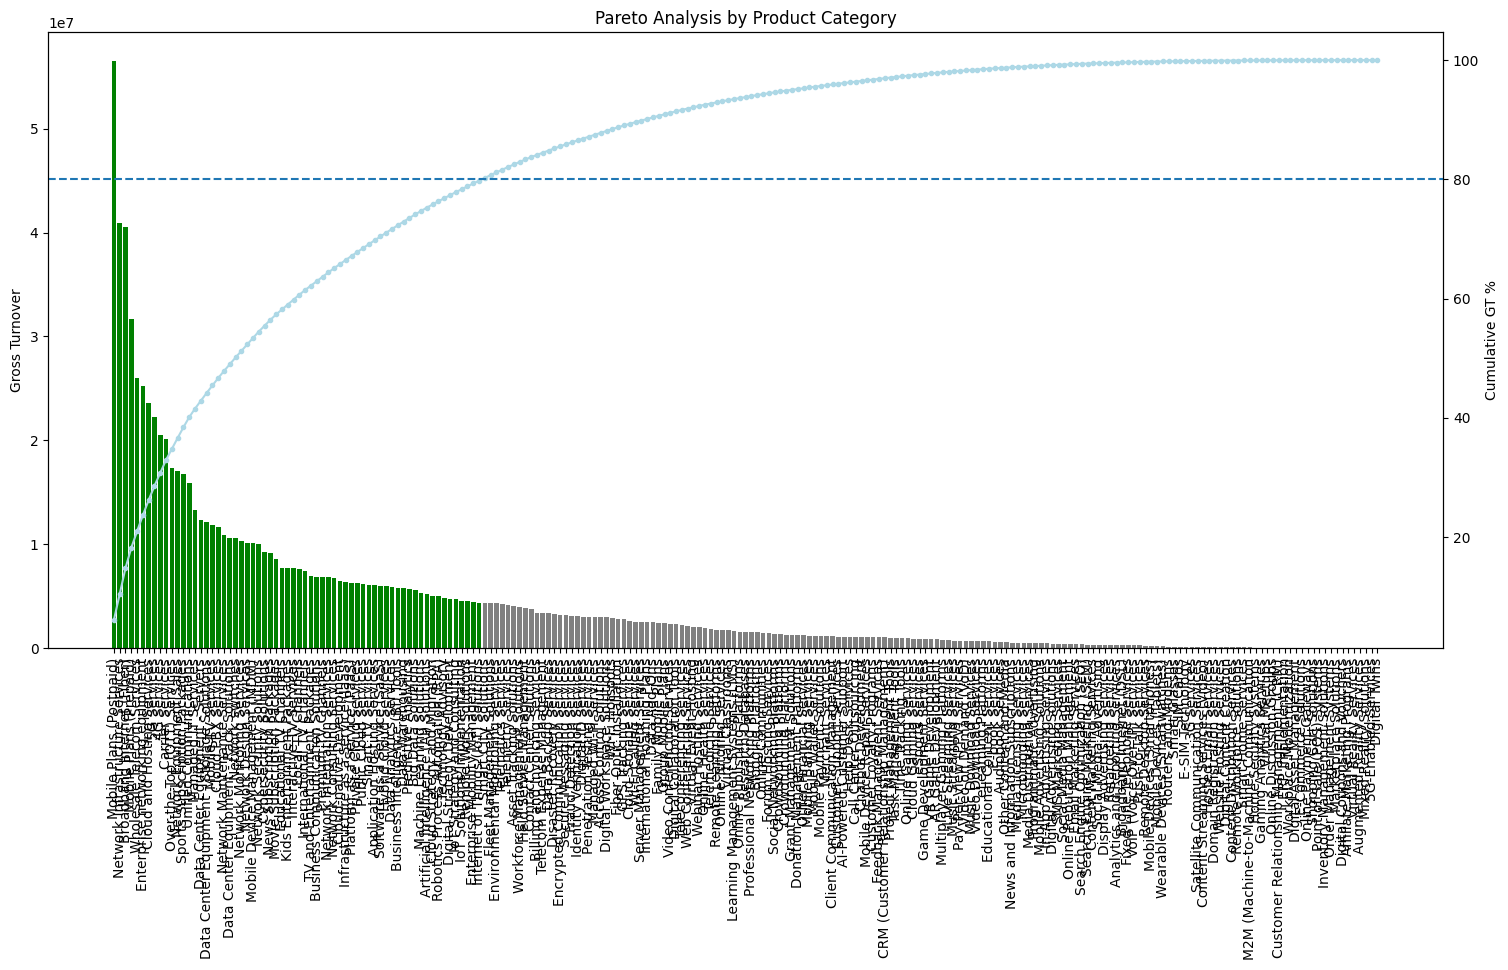

In [ ]:
#display pareto
fig, ax1 = plt.subplots(figsize=(18, 8))

# color bars based on cumulative percentage
colors = [
    "green" if x <= 80 else "grey"
    for x in df_Pareto["Cumulative_GT%"]
]

# bar chart
ax1.bar(
    df_Pareto["ProdCat2"],
    df_Pareto["GROSS_TURNOVER"],
    color=colors
)

ax1.set_ylabel("Gross Turnover")
ax1.tick_params(axis="x", rotation=90)

# cumulative line
ax2 = ax1.twinx()

ax2.plot(
    df_Pareto["ProdCat2"],
    df_Pareto["Cumulative_GT%"],
    marker="o",
    markersize=3,
    color="lightblue"
)

ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative GT %")

plt.title("Pareto Analysis by Product Category")

plt.show()

***Task 2.4: Perform the necessary action to map the top products from Pareto Analysis to the previously created master dataframe df_Filtered and store this in a new dataframe df_Filtered_Pareto.***

*Hint: Think Joins?*

In [ ]:
df_Filtered_Pareto = df_Filtered.merge(
    df_Pareto_80[["ProdCat2"]],
    how="inner",
    on="ProdCat2"
)

df_Filtered_Pareto.shape

(646864, 25)

In the above dataset, you will notice that there are some columns that are repititive and redundant.

***Task 2.5: Remove the redundant columns and give a meaningful name to the repititive columns***

In [ ]:
df_Filtered_Pareto = df_Filtered_Pareto.loc[:, ~df_Filtered_Pareto.columns.duplicated()].copy()

df_Filtered_Pareto.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,Main_account_ID,Customer_type,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Invoice_count,Invoice_flag,SKU_count,SKU_flag
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,103350,A-B,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,8581,1,8549,1
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,103350,A-B,4441429746,686.00,Predictive Analytics,Data and Analytics,8581,1,8549,1
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,103350,A-B,31592006,756.00,Mobile TV Services,Television and Entertainment,8581,1,8549,1
3,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,103350,A-B,JSF 505,809.00,4G Services,Broadband and Internet Services,8581,1,8549,1
4,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,103350,A-B,JSF 406,809.00,4G Services,Broadband and Internet Services,8581,1,8549,1


**This analysis gives an understanding of the top product portfolio of the company. This will be further used to perform customer segmentation.**

### 3. Customer Segmentation

The next part in this analysis is to find meaningful customer segments from the product purchase behaviour.

You will use **KMeans Clustering Algorithm** for this.

### KMeans Algorithm
The KMeans algorithm is a popular clustering technique used to partition a dataset into K clusters, where each data point belongs to the cluster with the nearest mean. Here are the steps involved in the KMeans algorithm:

**Initialization:**

- Choose the optimal number of clusters K, say 3 in this case.
- Randomly select K data points from the dataset as the initial centroids (cluster centers).

![image-2.png](attachment:image-2.png)

**Assignment Step:**

- Assign each data point to the nearest centroid. This is usually done by calculating the Euclidean distance between each data point and the centroids.
- Each data point is assigned to the cluster whose centroid is closest to it.

**Update Step:**

- Recalculate the centroids as the mean of all data points assigned to each cluster.
- The new centroid for each cluster is the average of the positions of all the data points in that cluster.

![image-3.png](attachment:image-3.png)

**Repeat:**

- Repeat the Assignment and Update steps until the centroids no longer change significantly or a specified number of iterations is reached.
- This convergence indicates that the clusters are stable, and the algorithm has found the optimal clustering.

![image-4.png](attachment:image-4.png)

**Termination:**

- The algorithm terminates when the centroids have stabilized (i.e., they do not change significantly between iterations) or after a pre-defined number of iterations.



To execute this analysis, **Main Account** and **ProdCat1** (is a broader product category and is at the highest level in the product hierarchy) data will be used.

*Note: ProdCat2 level data is at a very granular level and performing clustering analysis on this might not give meaningful clusters.*

To proceed with the customer segmentation analysis, you need to menaingfully prepare the data.

***Task 3.1: Transform the data to feed to the clustering algorithm***

- Create a copy of the above dataframe and save it as **df_segment**
- Create a Primary Key: Concatenate the Main Account (ID) and Main Account Name
- Execute a groupby operation to calculate the annual turnover of each customer for each product (ProdCat1)
- Calculate the % spend by each customer across different product categories

The resultant dataframe will have the following columns:
- Primary Key
- ProdCat1
- Gross_Turnover
- Customer Spend %

In [ ]:
df_segment = df_Filtered_Pareto.copy()

df_segment["Primary_Key"] = (
    df_segment["Main_account"].astype(str)
    + " - "
    + df_segment["Main_account_name"].astype(str)
)

df_segment = (
    df_segment.groupby(["Primary_Key", "ProdCat1"], as_index=False)["GROSS_TURNOVER"]
    .sum()
)

total_spend = df_segment.groupby("Primary_Key")["GROSS_TURNOVER"].transform("sum")

df_segment["Customer Spend %"] = df_segment["GROSS_TURNOVER"] / total_spend * 100

df_segment.head()

,Primary_Key,ProdCat1,GROSS_TURNOVER,Customer Spend %
0,100015 - Customer Group_2149,Broadband and Internet Services,9250.04,44.25
1,100015 - Customer Group_2149,Cloud and Hosting Services,124.69,0.60
2,100015 - Customer Group_2149,Devices and Accessories,132.17,0.63
3,100015 - Customer Group_2149,Digital Transformation Services,4106.33,19.65
4,100015 - Customer Group_2149,Mobile Services,123.71,0.59


***Task 3.2: Pivot the dataset to create a matrix view of spend % of all customers on all products (ProdCat1). Save the dataframe as df_pivot. Create another dataframe df_clustering removing the primary key from the df_pivot dataframe.***

In [ ]:
#Pivot for clustering

df_pivot = df_segment.pivot_table(
    index="Primary_Key",
    columns="ProdCat1",
    values="Customer Spend %",
    fill_value=0
).reset_index()

df_clustering = df_pivot.drop(columns=["Primary_Key"])

df_pivot.head()

ProdCat1,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,100015 - Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44
1,100022 - Customer Group_1631,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39
2,100027 - Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84
3,100040 - Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59
4,100041 - Customer Group_477,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77


### The Elbow Method in KMeans Clustering

The Elbow Method is a commonly used technique to determine the optimal number of clusters (K) in KMeans clustering. It helps to balance between underfitting and overfitting by finding a point where adding more clusters doesn’t significantly improve the model performance.

![image.png](attachment:image.png)

***Explanation of the Plot***

**WCSS (Within Cluster Sum of Squares) vs. Number of Clusters:**

- The x-axis represents the number of clusters (K).
- The y-axis represents the Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster.

**Plotting WCSS for Different K Values:**

- For each value of K (from 1 to 10), the KMeans algorithm is run, and the corresponding WCSS is calculated.
- The plot shows how WCSS decreases as the number of clusters increases.

**Elbow Point:**

- The red point marked on the plot indicates the "elbow point" where the rate of decrease in WCSS slows down.
- In this example, the elbow point is at K = 3. This suggests that 3 clusters are optimal for this dataset, as adding more clusters beyond this point results in only a marginal reduction in WCSS.

**Interpretation:**

- Before the Elbow Point: Adding more clusters significantly reduces WCSS, indicating that the clusters are becoming more defined and compact.
- After the Elbow Point: The reduction in WCSS slows down, meaning that adding more clusters doesn’t significantly improve the clustering.

**Conclusion**

The Elbow Method helps to identify the optimal number of clusters by looking for the point where the WCSS starts to decrease at a slower rate, balancing model complexity and performance. In this case, the plot suggests that using 3 clusters is a good choice for the dataset.

***Task 3.3: Run K-Means clustering algorithm and identify the optimal number of clusters using Elbow Method***

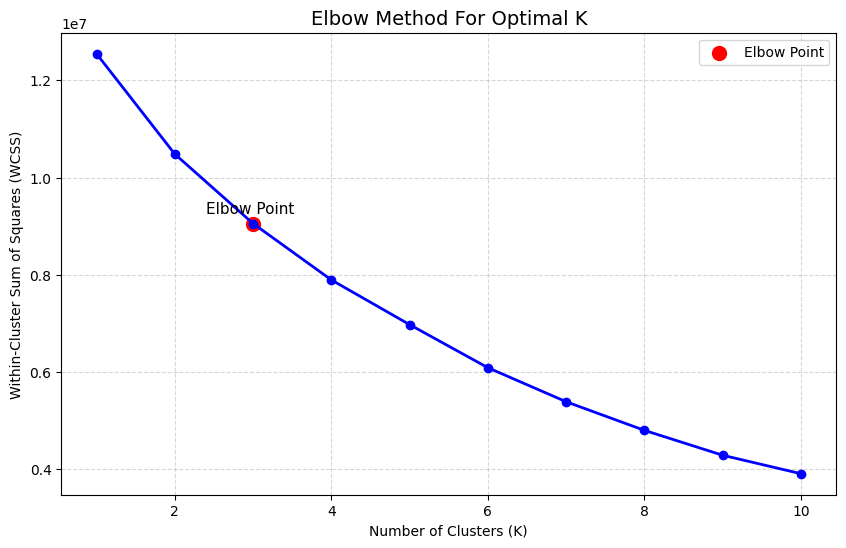

In [ ]:
wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_clustering)

    wcss.append(kmeans.inertia_)

# plot
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    wcss,
    marker="o",
    color="blue",
    linewidth=2
)

# highlight elbow point
plt.scatter(
    3,
    wcss[2],
    color="red",
    s=100,
    label="Elbow Point"
)

plt.text(
    2.4,
    wcss[2] + 200000,
    "Elbow Point",
    fontsize=11
)

plt.title("Elbow Method For Optimal K", fontsize=14)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()

plt.show()

The Elbow Curve provides an optimal value for 'k' that is the number of clusters to be generated in the output. This value can be used as a guideline for the actual clustering run; one may vary the number of clusers in the output based on business need.

***Task 3.4: Run the KMeans algorithm with optimal number of clusters***

In [ ]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pivot["Cluster"] = kmeans.fit_predict(df_clustering)

df_pivot.head()

ProdCat1,Primary_Key,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment,Cluster
0,100015 - Customer Group_2149,44.25,0.00,0.60,0.00,0.63,19.65,0.00,0.59,23.84,0.00,10.44,0
1,100022 - Customer Group_1631,0.00,18.88,6.79,0.00,12.55,0.00,0.00,5.43,10.35,44.61,1.39,0
2,100027 - Customer Group_2392,34.30,0.00,1.03,1.42,0.00,0.00,0.00,35.76,4.64,0.00,22.84,0
3,100040 - Customer Group_2150,0.00,5.05,4.29,0.00,0.00,0.00,0.00,0.66,89.41,0.00,0.59,1
4,100041 - Customer Group_477,23.34,5.27,1.18,0.85,6.21,3.94,0.00,12.24,29.98,0.24,16.77,0


***Task 3.5: From the above clusters, create cluster profile***

***Task 3.5.1: Map each customers to their respective cluster in df_segment dataset***

In [ ]:
df_segment = df_segment.merge(
    df_pivot[["Primary_Key", "Cluster"]],
    on="Primary_Key",
    how="left"
)

df_segment.head()

,Primary_Key,ProdCat1,GROSS_TURNOVER,Customer Spend %,Cluster
0,100015 - Customer Group_2149,Broadband and Internet Services,9250.04,44.25,0
1,100015 - Customer Group_2149,Cloud and Hosting Services,124.69,0.60,0
2,100015 - Customer Group_2149,Devices and Accessories,132.17,0.63,0
3,100015 - Customer Group_2149,Digital Transformation Services,4106.33,19.65,0
4,100015 - Customer Group_2149,Mobile Services,123.71,0.59,0


***Task 3.5.2: Create a cluster profile table with the cluster label, Gross Turnover for each cluster, Number of unique customers in each cluster, % share of Gross Turnover of each cluster for each product.***

*Illustrative: Here is a snapshot of the desired cluster profile:*
![image-2.png](attachment:image-2.png)

In [ ]:
# total gross turnover and unique customers per cluster
cluster_summary = (
    df_segment.groupby("Cluster", as_index=False)
    .agg(
        Gross_Turnover=("GROSS_TURNOVER", "sum"),
        Unique_Customers=("Primary_Key", "nunique")
    )
)

# gross turnover by cluster and product category
cluster_product = (
    df_segment.groupby(["Cluster", "ProdCat1"], as_index=False)
    .agg(
        Product_Gross_Turnover=("GROSS_TURNOVER", "sum")
    )
)

# calculate percentage share within each cluster
cluster_product["GT Share"] = (
    cluster_product["Product_Gross_Turnover"]
    / cluster_product.groupby("Cluster")["Product_Gross_Turnover"].transform("sum")
)

# convert product categories into columns
cluster_product_pivot = cluster_product.pivot_table(
    index="Cluster",
    columns="ProdCat1",
    values="GT Share",
    fill_value=0
).reset_index()

# combine cluster summary with product percentage table
cluster_profile = cluster_summary.merge(
    cluster_product_pivot,
    on="Cluster",
    how="left"
)

cluster_profile

,Cluster,Gross_Turnover,Unique_Customers,Broadband and Internet Services,Business Solutions,Cloud and Hosting Services,Data and Analytics,Devices and Accessories,Digital Transformation Services,IoT and Smart Solutions,Mobile Services,Network and Infrastructure,Security and Privacy,Television and Entertainment
0,0,558909378.90,2483,0.14,0.06,0.08,0.04,0.11,0.11,0.01,0.15,0.14,0.03,0.14
1,1,121630378.65,944,0.03,0.04,0.07,0.03,0.06,0.05,0.01,0.08,0.50,0.02,0.11
2,2,64504119.50,530,0.06,0.04,0.06,0.04,0.05,0.07,0.00,0.06,0.12,0.02,0.48


### 4. Prepare data for Tableau Dashboard

From here, you will be creating the visualizations in Tableau. But before, creating the required visualizations in Tableau, you should prepare the data.

Here is a reference of how data for visualizations for **Customer Segmentation** looks like:

![image-5.png](attachment:image-5.png)






Here is a reference of how data for visualizations for **Product Categorization** looks like:

![image-4.png](attachment:image-4.png)

where:

- Product ID: SKU ID
- Gross Turnover (sum), Amount (sum), Invoice_count (distinct count of invoices), Main_account_count (distinct count of main accounts): fields aggregated at SKU level
- Above columns with _percluster: fields aggregated at cluster level
- Frequency (%) : number of transactions the SKU appeared on, when compared to all transactions in a cluster
- Customer Prevalence (%) within cluster : Percentage of customers within a cluster who purchase the SKU



In [ ]:
df_customer_segmentation = df_segment.copy()
df_customer_segmentation.to_csv("customer_segmentation_tableau.csv", index=False)

In [ ]:
df_tableau = df_Filtered_Pareto.copy()

df_tableau["Primary_Key"] = (
    df_tableau["Main_account"].astype(str)
    + " - "
    + df_tableau["Main_account_name"].astype(str)
)

df_tableau = df_tableau.merge(
    df_pivot[["Primary_Key", "Cluster"]],
    on="Primary_Key",
    how="left"
)

df_tableau.head()

,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,...,ProductID,ProductCategoryID,ProdCat2,ProdCat1,Invoice_count,Invoice_flag,SKU_count,SKU_flag,Primary_Key,Cluster
0,47154,124195645,10,2022-09-09,15082,103350,Customer Group_24,Responsible Employee_17,5737657492,ZLAG,...,5737657492,605.00,Cloud Strategy and Migration,Digital Transformation Services,8581,1,8549,1,103350 - Customer Group_24,0
1,47184,124167744,70,2022-09-07,15082,103350,Customer Group_24,Responsible Employee_17,4441429746,ZLAG,...,4441429746,686.00,Predictive Analytics,Data and Analytics,8581,1,8549,1,103350 - Customer Group_24,0
2,48255,124385024,480,2022-10-10,15082,103350,Customer Group_24,Responsible Employee_17,31592006,ZLAG,...,31592006,756.00,Mobile TV Services,Television and Entertainment,8581,1,8549,1,103350 - Customer Group_24,0
3,48315,123063686,10,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 505,ZLAG,...,JSF 505,809.00,4G Services,Broadband and Internet Services,8581,1,8549,1,103350 - Customer Group_24,0
4,48316,123063686,30,2022-03-02,15082,103350,Customer Group_24,Responsible Employee_17,JSF 406,ZLAG,...,JSF 406,809.00,4G Services,Broadband and Internet Services,8581,1,8549,1,103350 - Customer Group_24,0


In [ ]:
#product categorization dataset
df_product_level = (
    df_tableau.groupby(["Cluster", "PRODUCT", "ProdCat1", "ProdCat2"], as_index=False)
    .agg(
        Gross_Turnover=("GROSS_TURNOVER", "sum"),
        Amount=("AMOUNT", "sum"),
        Invoice_count=("INVOICE_NUMBER", "nunique"),
        Main_account_count=("Main_account", "nunique")
    )
)

df_product_level.head()

,Cluster,PRODUCT,ProdCat1,ProdCat2,Gross_Turnover,Amount,Invoice_count,Main_account_count
0,0,1,Data and Analytics,Data Analytics Services,71.70,4,2,2
1,0,1000,Data and Analytics,Data Analytics Services,8043.06,556,14,13
2,0,10000086294,Network and Infrastructure,Network Infrastructure Services,15067.88,30,3,1
3,0,10000263597,Network and Infrastructure,Wholesale Telecom Services,696.12,6,1,1
4,0,10000435227,Cloud and Hosting Services,Infrastructure as a Service (IaaS),2188.59,81,1,1


In [ ]:
# Add frequency and customer prevalence

cluster_txn_count = (
    df_tableau.groupby("Cluster")["INVOICE_NUMBER"]
    .transform("count")
)

cluster_customer_count = (
    df_tableau.groupby("Cluster")["Main_account"]
    .transform("nunique")
)

df_tableau["Cluster_Transaction_Count"] = cluster_txn_count
df_tableau["Cluster_Customer_Count"] = cluster_customer_count

product_frequency = (
    df_tableau.groupby(["Cluster", "PRODUCT"], as_index=False)
    .agg(
        Product_Transaction_Count=("INVOICE_NUMBER", "count"),
        Product_Customer_Count=("Main_account", "nunique"),
        Cluster_Transaction_Count=("Cluster_Transaction_Count", "max"),
        Cluster_Customer_Count=("Cluster_Customer_Count", "max")
    )
)

product_frequency["Frequency (%)"] = (
    product_frequency["Product_Transaction_Count"]
    / product_frequency["Cluster_Transaction_Count"] * 100
)

product_frequency["Customer Prevalence (%)"] = (
    product_frequency["Product_Customer_Count"]
    / product_frequency["Cluster_Customer_Count"] * 100
)

product_frequency.head()

,Cluster,PRODUCT,Product_Transaction_Count,Product_Customer_Count,Cluster_Transaction_Count,Cluster_Customer_Count,Frequency (%),Customer Prevalence (%)
0,0,1,2,2,471164,2483,0.00,0.08
1,0,1000,14,13,471164,2483,0.00,0.52
2,0,10000086294,3,1,471164,2483,0.00,0.04
3,0,10000263597,1,1,471164,2483,0.00,0.04
4,0,10000435227,1,1,471164,2483,0.00,0.04


In [ ]:
# tableau export

df_product_tableau = df_product_level.merge(
    product_frequency[
        ["Cluster", "PRODUCT", "Frequency (%)", "Customer Prevalence (%)"]
    ],
    on=["Cluster", "PRODUCT"],
    how="left"
)

df_product_tableau.to_csv("product_categorization_tableau.csv", index=False)

df_product_tableau.head()

,Cluster,PRODUCT,ProdCat1,ProdCat2,Gross_Turnover,Amount,Invoice_count,Main_account_count,Frequency (%),Customer Prevalence (%)
0,0,1,Data and Analytics,Data Analytics Services,71.70,4,2,2,0.00,0.08
1,0,1000,Data and Analytics,Data Analytics Services,8043.06,556,14,13,0.00,0.52
2,0,10000086294,Network and Infrastructure,Network Infrastructure Services,15067.88,30,3,1,0.00,0.04
3,0,10000263597,Network and Infrastructure,Wholesale Telecom Services,696.12,6,1,1,0.00,0.04
4,0,10000435227,Cloud and Hosting Services,Infrastructure as a Service (IaaS),2188.59,81,1,1,0.00,0.04


***The End***